# **Import Libraries**

In [36]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler

# **Load Dataset**

In [37]:
df = pd.read_csv('retail_store_sales.csv')
print(df.head())

  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3              NaN  
4          

# **Data Cleaning, Split Features and Target**

In [38]:
df = df.dropna()
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# **Convert Categorical Data**

In [39]:
X = pd.get_dummies(X)



---



---



# **FEATURE SELECTION**

In [40]:


# Convert y (VERY IMPORTANT)
from sklearn.preprocessing import LabelEncoder
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature Selection
selector = SelectKBest(score_func=f_regression, k=5)
X_selected = selector.fit_transform(X_scaled, y)

In this experiment, I used the Retail Store Sales dataset to identify the most important features affecting sales.

First, I loaded the dataset containing retail store information such as product details, store data, and sales values.
I cleaned the dataset by removing missing values to ensure accurate analysis.
Then, I separated the dataset into:
Input features (X) → all columns except the last column
Target variable (y) → sales (last column)
Since the dataset may contain categorical values (like product category, store type, etc.), I converted them into numerical format using one-hot encoding.
After that, I standardized the data using StandardScaler to ensure all features are on the same scale.
I applied SelectKBest feature selection with f_regression to select the top 5 most important features influencing sales.
Finally, I displayed the selected features.

Conclusion:
The most relevant features affecting retail sales were successfully identified from the dataset.



---



---



# **PCA (Principal Component Analysis)**

In [41]:
# Load dataset
df = pd.read_csv('retail_store_sales.csv')

# Remove missing values
df = df.dropna()

# Select features
X = df.iloc[:, :-1]

# Convert categorical to numeric
X = pd.get_dummies(X)

# Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Output
print("PCA Output Shape:", X_pca.shape)

PCA Output Shape: (7579, 2)


**Description:**

In this part, I applied Principal Component Analysis (PCA) on the Retail Store Sales dataset to reduce dimensionality.

I loaded and cleaned the dataset.
I selected only the input features (excluding the sales column).
I converted categorical features into numerical format using one-hot encoding.
Then, I standardized the dataset using StandardScaler.
After preprocessing, I applied PCA to reduce the number of features into 2 principal components.
PCA transformed the original features into new components that capture the maximum variance in the data.

Conclusion:
The dataset was successfully reduced into fewer dimensions while preserving important information, making it easier for further analysis.



---



---



# **VARIANCE VISUALIZATION**

In [42]:

# Explained variance
explained_variance = pca.explained_variance_ratio_




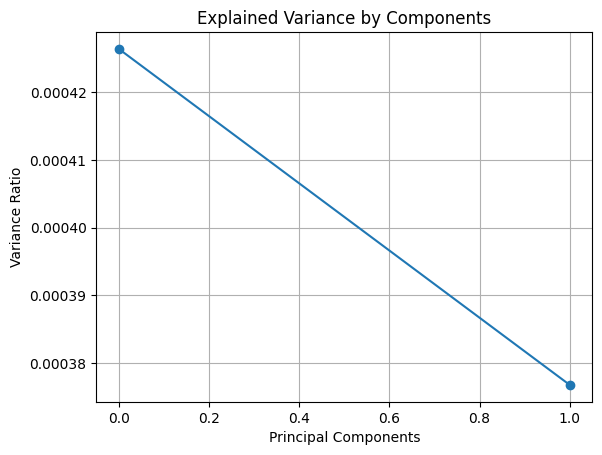

In [43]:
# Plot individual variance
plt.figure()
plt.plot(explained_variance, marker='o')
plt.title("Explained Variance by Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.grid()
plt.show()

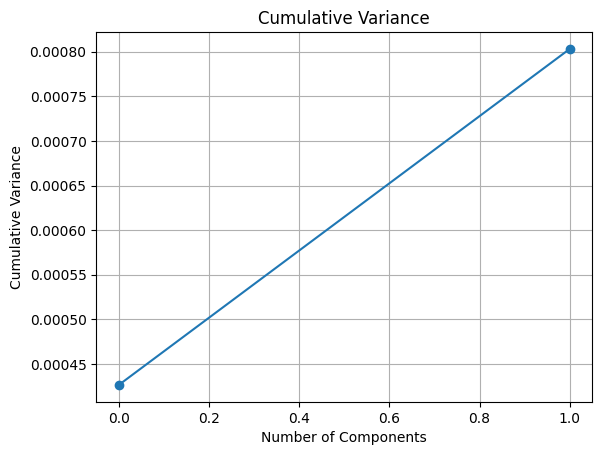

In [44]:

# Plot cumulative variance
cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(cumulative_variance, marker='o')
plt.title("Cumulative Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.show()



In this step, I visualized how much information each principal component captures.

After applying PCA on the Retail Store Sales dataset, I calculated the explained variance ratio for each component.
This shows how much variance (information) each principal component represents.
I plotted:
Individual Variance Plot → shows contribution of each component
Cumulative Variance Plot → shows total variance captured
The cumulative graph helps in identifying how many components are required to retain most of the information (typically 90–95%).

Conclusion:
The variance plots helped determine the optimal number of principal components required for efficient dimensionality reduction.